# Name:Pratiksha Dhondiram Khot
# Rollno:CO2033

# Loan Status Prediction using Machine Learning with Python

## 1.Problem Statement

#### The objective of this project is to build a machine learning model that predicts whether a loan application will be approved or rejected based on the applicant's demographic and financial information.  A predictive model can help banks make faster and more consistent loan approval decisions while reducing risk.


## 2.Dataset Information

#### A loan Status Prediction dataset contains information about applicants,including their personal,financial,and loan related details
#### - Dataset Name: Loan Status Prediction dataset
#### - Target Variable: Y → Loan Approved, N → Loan Rejected
#### -Domain: Banking and Finance

## 3.Importing Library

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

print("Library successfully importing")

Library successfully importing


## 4.Data Loading

In [2]:
df = pd.read_csv("loan_data.csv")
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
376,LP002953,Male,Yes,3+,Graduate,No,5703,0.0,128.0,360.0,1.0,Urban,Y
377,LP002974,Male,Yes,0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
378,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
379,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y


In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
4,LP001013,Male,Yes,0,Not Graduate,No,2333,1516.0,95.0,360.0,1.0,Urban,Y


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381 entries, 0 to 380
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            381 non-null    object 
 1   Gender             376 non-null    object 
 2   Married            381 non-null    object 
 3   Dependents         373 non-null    object 
 4   Education          381 non-null    object 
 5   Self_Employed      360 non-null    object 
 6   ApplicantIncome    381 non-null    int64  
 7   CoapplicantIncome  381 non-null    float64
 8   LoanAmount         381 non-null    float64
 9   Loan_Amount_Term   370 non-null    float64
 10  Credit_History     351 non-null    float64
 11  Property_Area      381 non-null    object 
 12  Loan_Status        381 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 38.8+ KB


In [5]:
df.shape

(381, 13)

In [6]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [7]:
df.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

## 5.Dataset cleaning

In [8]:
df.isnull().sum()

Loan_ID               0
Gender                5
Married               0
Dependents            8
Education             0
Self_Employed        21
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     11
Credit_History       30
Property_Area         0
Loan_Status           0
dtype: int64

In [9]:
# Fill Missing Values
df['Gender'] = df['Gender'].fillna(df['Gender'].mode()[0])
df['Married'] = df['Married'].fillna(df['Married'].mode()[0])
df['Dependents'] = df['Dependents'].fillna(df['Dependents'].mode()[0])
df['Self_Employed'] = df['Self_Employed'].fillna(df['Self_Employed'].mode()[0])

df['LoanAmount'] = df['LoanAmount'].fillna(df['LoanAmount'].median())
df['Loan_Amount_Term'] = df['Loan_Amount_Term'].fillna(df['Loan_Amount_Term'].mode()[0])
df['Credit_History'] = df['Credit_History'].fillna(df['Credit_History'].mode()[0])

In [10]:
df.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [11]:
#Check Duplicates
df.duplicated().sum()

0

## 6.Exploratory Data Analysis (EDA)

### 1.Count plot

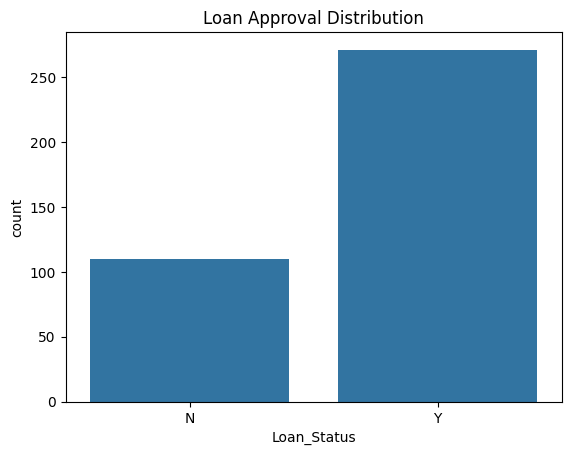

In [12]:
sns.countplot(x='Loan_Status', data=df)
plt.title("Loan Approval Distribution")
plt.show()

### 2.Hisogram

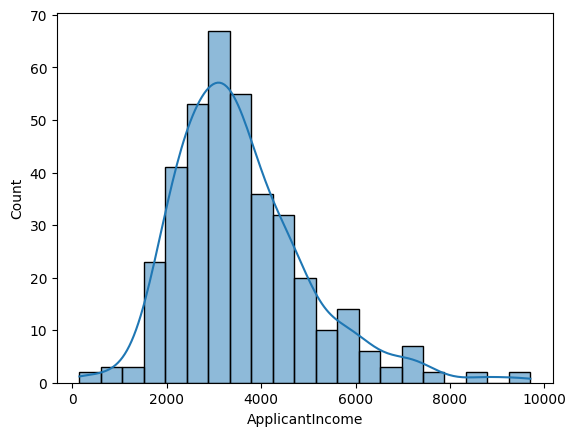

In [13]:
sns.histplot(df['ApplicantIncome'], kde=True)
plt.show()

### 3.Correlation Heatmap

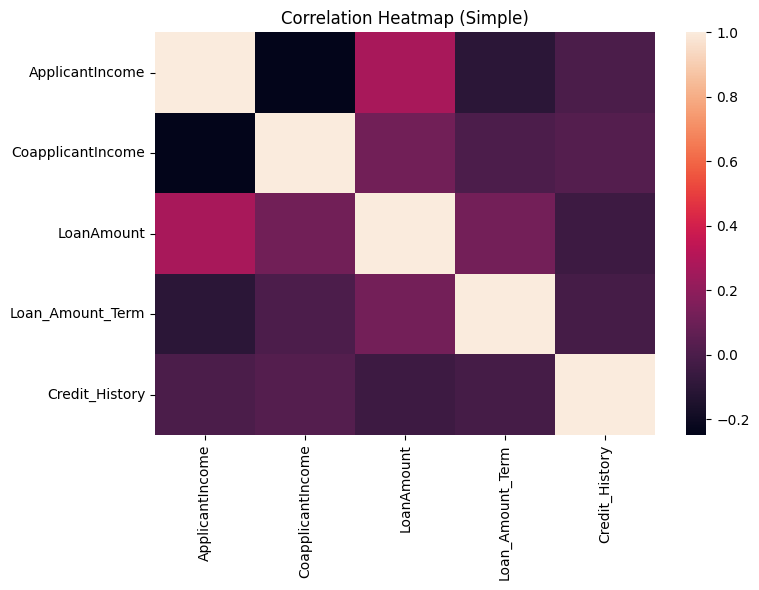

In [14]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(8,6)) 
sns.heatmap(corr)
plt.title('Correlation Heatmap (Simple)') 
plt.tight_layout()
plt.show()

### 4.Violin plot

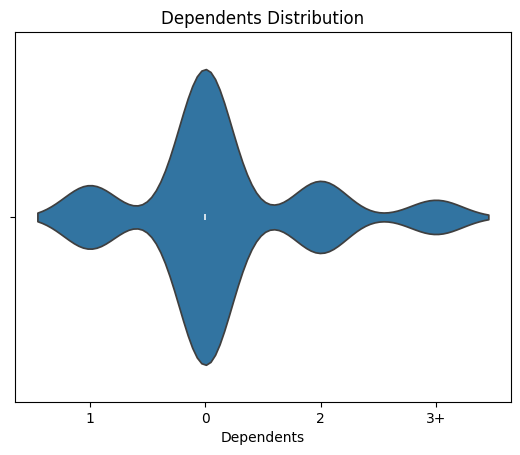

In [15]:
sns.violinplot(x='Dependents', data=df)
plt.title("Dependents Distribution")
plt.show()

### 5.pair plot

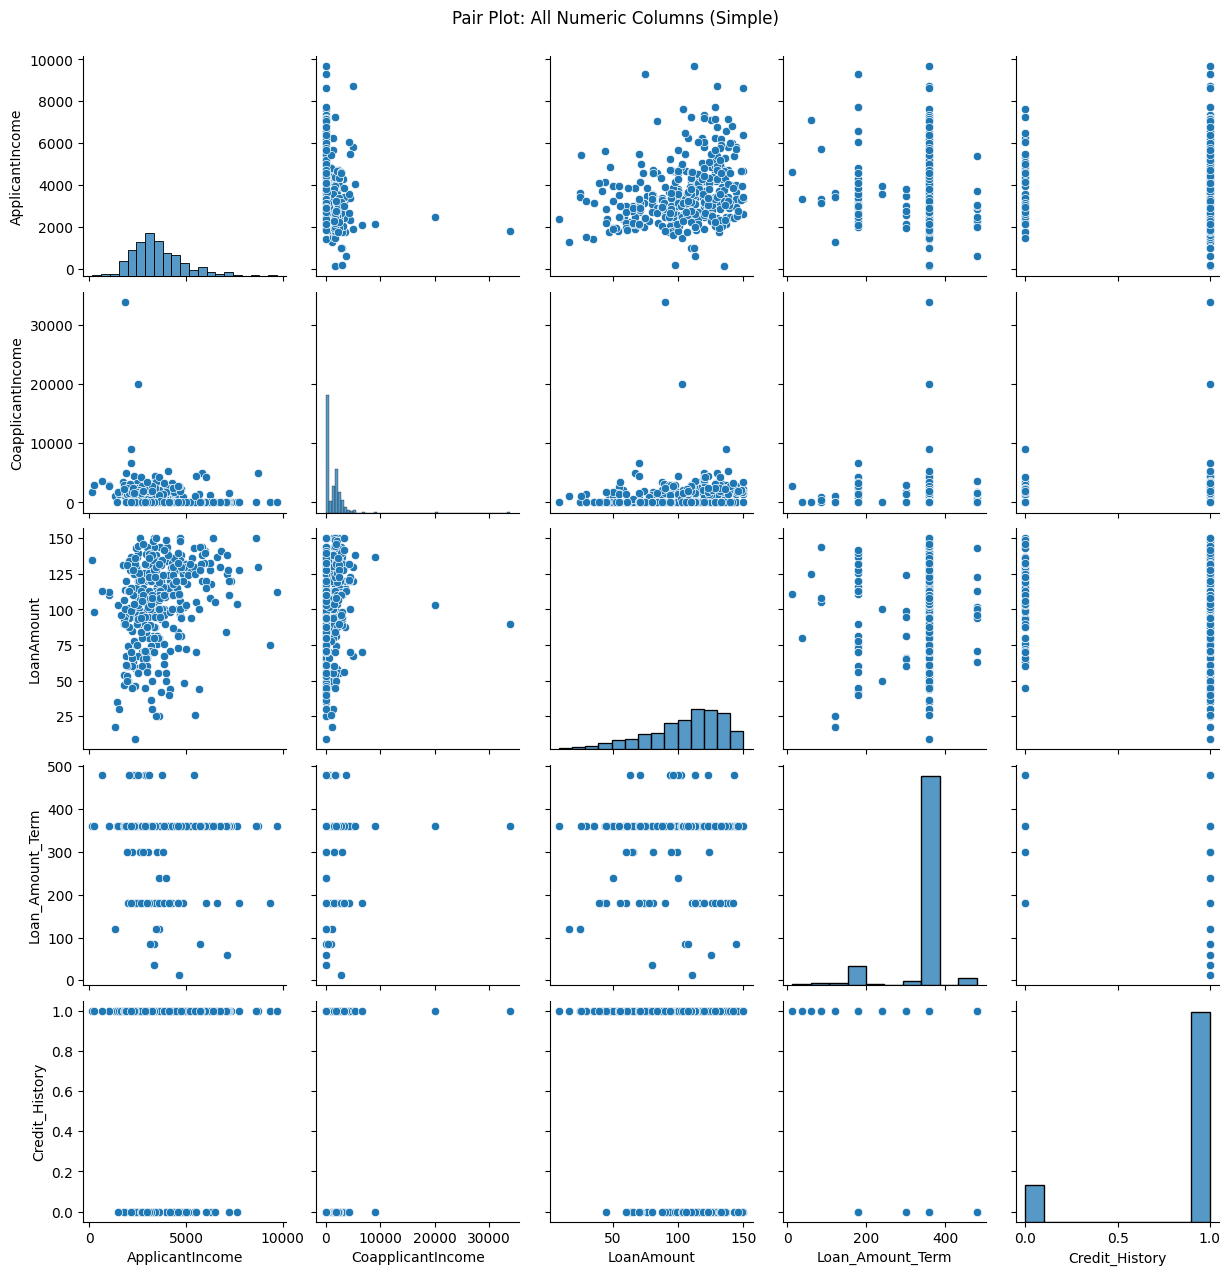

In [16]:
sns.pairplot(df)
plt.suptitle('Pair Plot: All Numeric Columns (Simple)', y=1.02) 
plt.show()

### 6.Box plot

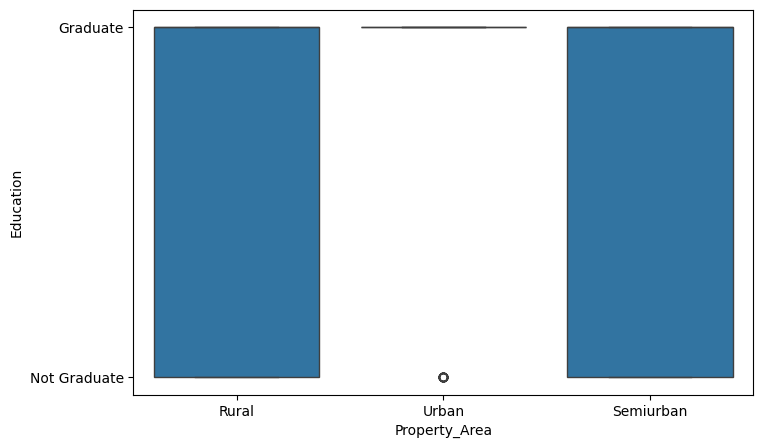

In [17]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Property_Area', y='Education', data=df)
plt.show()

### 7.Scatter plot

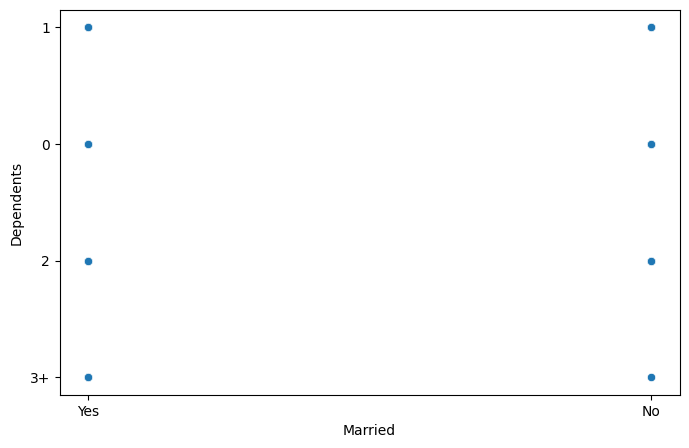

In [18]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Married', y='Dependents', data=df)
plt.show()

### 8.Joint plot

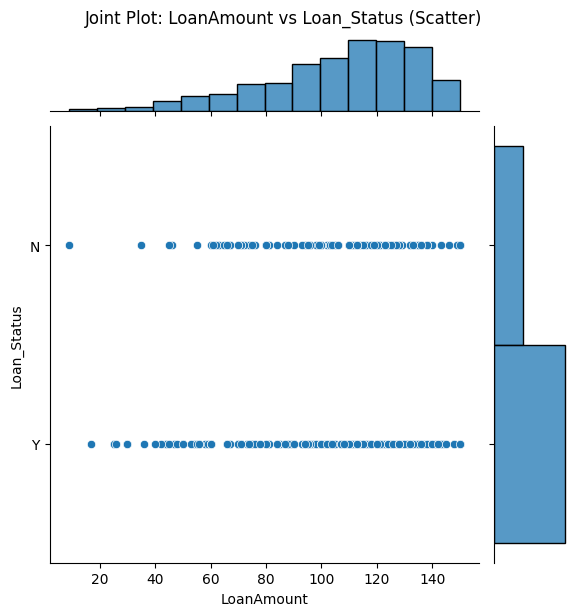

In [19]:
sns.jointplot(data=df, x='LoanAmount', y='Loan_Status', height=6) 
plt.suptitle('Joint Plot: LoanAmount vs Loan_Status (Scatter)', y=1.02) 
plt.show()

### 9.Line plot

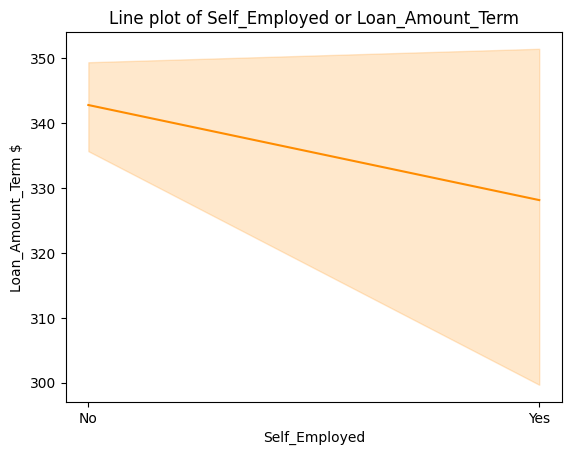

In [20]:
sns.lineplot(data=df, x="Self_Employed", y="Loan_Amount_Term", color='darkorange')
plt.title("Line plot of Self_Employed or Loan_Amount_Term")
plt.xlabel("Self_Employed")                     
plt.ylabel("Loan_Amount_Term $")
plt.show()

### 10.Relplot

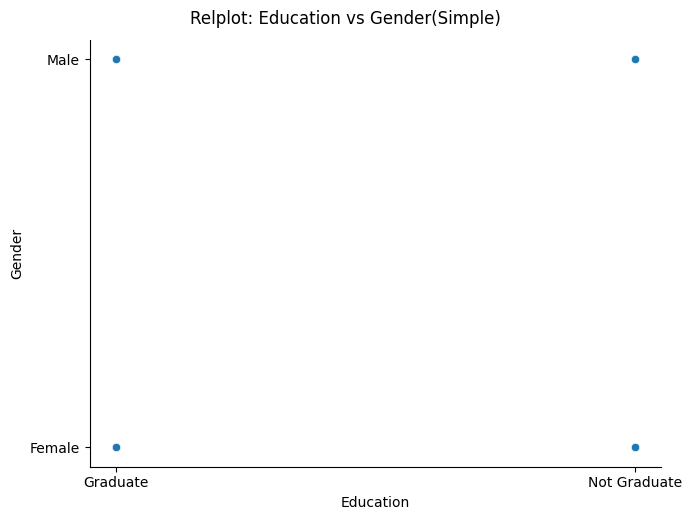

In [21]:
sns.relplot(data=df, x='Education', y='Gender', height=5, aspect=1.4) 
plt.suptitle('Relplot: Education vs Gender(Simple)', y=1.03) 
plt.show()

## 7.Feature Engineering

In [22]:
X = df.drop("Loan_Status", axis=1)
y = df["Loan_Status"]

In [23]:
print(X.shape)
print(y.shape)

(381, 12)
(381,)


### Feature Scaling

In [24]:
X = df.drop(["Loan_ID", "Loan_Status"], axis=1)
y = df["Loan_Status"]

In [25]:
print(X.select_dtypes(include=['object']).columns)

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')


In [26]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

In [27]:
X = pd.get_dummies(X, drop_first=True)

### Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,random_state=42
)

In [29]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(304, 14)
(77, 14)
(304,)
(77,)


## 8.Model Building

In [30]:
#Logistic Regression
lr = LogisticRegression(max_iter=5000)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_pred

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y'],
      dtype=object)

In [31]:
#Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)
dt_pred

array(['Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'N', 'N', 'N', 'Y', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'N', 'N', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N'],
      dtype=object)

In [32]:
#Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_pred

array(['Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'N', 'Y', 'N', 'N',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y',
       'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'N', 'Y',
       'Y', 'Y', 'N', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y', 'Y'],
      dtype=object)

## 9.Model Evaluation

In [33]:
#Logistic Regression
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(confusion_matrix(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

Accuracy: 0.8181818181818182
[[ 7 14]
 [ 0 56]]
              precision    recall  f1-score   support

           N       1.00      0.33      0.50        21
           Y       0.80      1.00      0.89        56

    accuracy                           0.82        77
   macro avg       0.90      0.67      0.69        77
weighted avg       0.85      0.82      0.78        77



In [34]:
#Decision Tree
print("Accuracy:", accuracy_score(y_test, dt_pred))
print(confusion_matrix(y_test, dt_pred))
print(classification_report(y_test, dt_pred))

Accuracy: 0.7402597402597403
[[ 8 13]
 [ 7 49]]
              precision    recall  f1-score   support

           N       0.53      0.38      0.44        21
           Y       0.79      0.88      0.83        56

    accuracy                           0.74        77
   macro avg       0.66      0.63      0.64        77
weighted avg       0.72      0.74      0.73        77



In [35]:
#Random Forest
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(confusion_matrix(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

Accuracy: 0.8051948051948052
[[ 7 14]
 [ 1 55]]
              precision    recall  f1-score   support

           N       0.88      0.33      0.48        21
           Y       0.80      0.98      0.88        56

    accuracy                           0.81        77
   macro avg       0.84      0.66      0.68        77
weighted avg       0.82      0.81      0.77        77



In [38]:
#Accuracy Comparison
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']

accuracy = [
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]
accuracy

[0.8181818181818182, 0.7402597402597403, 0.8051948051948052]

## 10.Conclusion

#### The dataset was successfully cleaned by handling missing values and removing unnecessary columns. Exploratory Data Analysis revealed that Credit History is the most influential factor affecting loan approval. Categorical variables were encoded for machine learning models.
#### Three classification models were trained:Logistic Regression, Decision Tree, Random Forest. The models were evaluated using Accuracy, Confusion Matrix, and Classification Report.